# This code trains a LSTM to predict if the news are true or fake based on https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification/code

## Victoria Knapp Perez and Jason LaRuez

In [1]:
! pip install -Uqq fastbook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 88.2 MB/s eta 0:00:00


In [2]:
import fastbook

# Importing data
import kagglehub
import os
import json


import matplotlib.pyplot as plt # Plotting
import pandas as pd # Pandas dataframes
import numpy as np

from fastbook import *
from fastai.text.all import *
import torch
import string

from fastai.callback.tracker import SaveModelCallback, EarlyStoppingCallback #early stopper
from fastai.callback.rnn import RNNRegularizer #Regulariza RNN
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix #Analytics tools
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer



In [3]:
from google.colab import drive
drive.mount('/content/drive')

out_dir = '/content/drive/MyDrive/NLPforFakeNews'
os.makedirs(out_dir, exist_ok=True)

# Add this directory to Python's search path
sys.path.append(out_dir)
from PreProcessingDataset import PreprocessDataOneDF

Mounted at /content/drive


In [4]:


# Download kaggle dataset from https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset/data
path = kagglehub.dataset_download("saurabhshahane/fake-news-classification")



100%|██████████| 92.1M/92.1M [00:05<00:00, 17.9MB/s]

Extracting files...


In [5]:
files = os.listdir(path)
files #See which files are inside

['WELFake_Dataset.csv']

In [6]:
news_file = os.path.join(path, "WELFake_Dataset.csv")

df_news = pd.read_csv(news_file) #Read csv file as pd




In [7]:
# Clean dataset with PreprocessData
train_df, val_df, test_df = PreprocessDataOneDF(
    df_news, 0.7, 0.2, 0.1,
    tfidf_radius=0.05, dedup_within_label=True,
    post_cross_exact_dedup=True,
    post_cross_near_dedup=True, post_radius=0.03
)
print("Split sizes:", len(train_df), len(val_df), len(test_df))
print("Train label counts:\n", train_df['label'].value_counts().sort_index())
print("Val   label counts:\n",   val_df['label'].value_counts().sort_index())
print("Test  label counts:\n",  test_df['label'].value_counts().sort_index())


Split sizes: 43048 12298 6150
Train label counts:
 label
0    24010
1    19038
Name: count, dtype: int64
Val   label counts:
 label
0    6859
1    5439
Name: count, dtype: int64
Test  label counts:
 label
0    3430
1    2720
Name: count, dtype: int64


In [8]:
import inspect
print('\n'.join([line for line in inspect.getsource(PreprocessDataOneDF).split('\n') if 'np' in line]))


    if not np.isclose(s, 1.0, atol=1e-6):
        raise ValueError("Input df must contain 'text' and 'label' columns.")
    if not set(np.unique(df['label'])).issubset({0,1}):


In [9]:
#Save the datasets
proc_dir = os.path.join(out_dir, "processed_datasets")
os.makedirs(proc_dir, exist_ok=True)

# Define file paths inside that folder
train_path = os.path.join(proc_dir, "train_FvT.csv")
val_path   = os.path.join(proc_dir, "val_FvT.csv")
test_path  = os.path.join(proc_dir, "test_FvT.csv")


train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)


In [10]:
# Read the datasets
train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

In [11]:

# Combine training and validation dataset for dataloader and learner
df_combined = pd.concat([train_df, val_df], ignore_index=True)
valid_idx = range(len(train_df), len(df_combined))

# Logistic regression

In [32]:
def clean_and_tokenize(text):
    """Removes punctuation, converts to lowercase, and tokenizes text."""
    if isinstance(text, str):
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = text.lower()
        return text.split()
    return [] # Return empty list for non-string inputs

In [33]:
train_df.dropna(subset=['text_full'], inplace=True)
val_df.dropna(subset=['text_full'], inplace=True)
test_df.dropna(subset=['text_full'], inplace=True)

In [34]:
start_time = time.time()

stop_words = ["i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours", "yourself",
              "yourselves", "he", "him", "his", "himself", "she", "her", "hers", "herself", "it", "its", "itself",
              "they", "them", "their", "theirs", "themselves", "what", "which", "who", "whom", "this", "that",
              "these", "those", "am", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had",
              "having", "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if", "or", "because",
              "as", "until", "while", "of", "at", "by", "for", "with", "about", "against", "between", "into",
              "through", "during", "before", "after", "above", "below", "to", "from", "up", "down", "in", "out",
              "on", "off", "over", "under", "again", "further", "then", "once", "here", "there", "when", "where",
              "why", "how", "all", "any", "both", "each", "few", "more", "most", "other", "some", "such", "no",
              "nor", "not", "only", "own", "same", "so", "than", "too", "very", "s", "t", "can", "will", "just",
              "don", "should", "now"]

np.random.seed(42)

train_val_df = pd.concat([train_df, val_df], ignore_index=True)
X_train_val = train_val_df['text_full'].values
y_train_val = train_val_df['label'].values
X_test = test_df['text_full'].values
y_test = test_df['label'].values

train_indices = train_df.index.tolist()
val_indices = [i + len(train_df) for i in val_df.index.tolist()]
custom_cv = [(train_indices, val_indices)]

tfidf = TfidfVectorizer(strip_accents=None, lowercase=False, preprocessor=None)

small_param_grid = [{
    'vect__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'vect__stop_words': [stop_words, None],
    'vect__tokenizer': [clean_and_tokenize],
    'clf__penalty': ['l1', 'l2'],
    'clf__C': [1.0, 5.0, 10.0]
}]

lr_tfidf = Pipeline([
    ('vect', tfidf),
    ('clf', LogisticRegression(solver='liblinear'))
])

gs_lr_tfidf = GridSearchCV(
    lr_tfidf,
    small_param_grid,
    scoring='accuracy',
    cv=custom_cv,
    verbose=2,
    n_jobs=-1
)

gs_lr_tfidf.fit(X_train_val, y_train_val)

print(f'\nBest parameter set: {gs_lr_tfidf.best_params_}')
print(f'Validation Accuracy: {gs_lr_tfidf.best_score_:.3f}')

clf = gs_lr_tfidf.best_estimator_
print(f'Test Accuracy: {clf.score(X_test, y_test):.3f}')

# -------------------- End timer --------------------
end_time = time.time()
elapsed = end_time - start_time
print(f"\nTotal runtime: {elapsed/60:.2f} minutes ({elapsed:.1f} seconds)\n")

Fitting 1 folds for each of 36 candidates, totalling 36 fits


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



Best parameter set: {'clf__C': 10.0, 'clf__penalty': 'l1', 'vect__ngram_range': (1, 2), 'vect__stop_words': None, 'vect__tokenizer': <function clean_and_tokenize at 0x7f491a8c3ec0>}
Validation Accuracy: 0.966
Test Accuracy: 0.972

Total runtime: 13.58 minutes (814.7 seconds)



In [26]:
y_pred = clf.predict(X_test)

# Compute weighted metrics (accounts for class imbalance)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"\nTest Precision: {precision:.3f}")
print(f"Test Recall:    {recall:.3f}")

# Optional: detailed per-class report
print("\nDetailed classification report:")
print(classification_report(y_test, y_pred))


Test Precision: 0.970
Test Recall:    0.967

Detailed classification report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3430
           1       0.97      0.97      0.97      2719

    accuracy                           0.97      6149
   macro avg       0.97      0.97      0.97      6149
weighted avg       0.97      0.97      0.97      6149



In [45]:
y_prob = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print(f"Test ROC–AUC:  {roc_auc:.4f}")



Test ROC–AUC:  0.9958


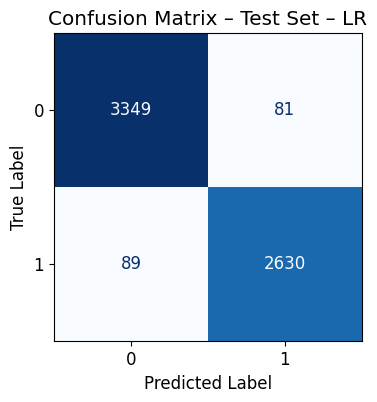

In [39]:
cm = confusion_matrix(y_test, y_pred)
labels_sorted = clf.classes_  # class order used by the model

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title("Confusion Matrix – Test Set – LR")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)

# Save figure
img_dir = Path(out_dir) / "imgs"
os.makedirs(img_dir, exist_ok=True)
save_path = img_dir / "CM-LR.jpg"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

# Training LLM encoder

In [15]:

#Relabel columns
df_combined = df_combined.rename(columns={'text_full':'text'})
df_combined['text']  = df_combined['text'].astype(str)
df_combined['label'] = df_combined['label'].astype(str).str.strip()


# 1) Text block for LM
tb_lm = TextBlock.from_df(
    'text',
    is_lm=True,
    seq_len=80
)

# 2) DataBlock with explicit IndexSplitter
dblock_lm = DataBlock(
    blocks=tb_lm,                      # only X for LM; Y is auto-shifted
    get_x=ColReader('text'),
    splitter=IndexSplitter(valid_idx)
)

# 3) Build LM DataLoaders
dls_lm = dblock_lm.dataloaders(
    df_combined,
    bs=128
)


In [16]:
cbs = [
    RNNRegularizer(alpha=2., beta=1.),
    GradientClip(1.0),
    SaveModelCallback(monitor='valid_loss', fname='finetuned', with_opt=False),
    EarlyStoppingCallback(monitor='valid_loss', patience=1),
] #Early stopper

learn = language_model_learner(
    dls_lm, AWD_LSTM,
    drop_mult=0.7, metrics=[accuracy, Perplexity()], wd=0.1, cbs=cbs,
    pretrained=True  # <- keep pretrained
).to_fp16()  #Learner

learn.path = Path(out_dir) / 'LSTM_parameters'
learn.path.mkdir(parents=True, exist_ok=True)  # make sure it exists
learn.model_dir = '.'

# training schedule
learn.unfreeze()
learn.fit_one_cycle(3, lr_max=slice(5e-5, 5e-3), wd=0.1) #3 training epochs

learn.load('finetuned') #Get best epoch from cbs

# Save model

learn.save_encoder('finetuned')


epoch,train_loss,valid_loss,accuracy,perplexity,time
0,3.861894,3.725142,0.340681,41.477123,19:29
1,3.780764,3.639825,0.350861,38.085167,19:14
2,3.724645,3.608369,0.354570,36.905807,19:16


Better model found at epoch 0 with valid_loss value: 3.725142002105713.
Better model found at epoch 1 with valid_loss value: 3.639824867248535.
Better model found at epoch 2 with valid_loss value: 3.6083688735961914.


# Text classifier

In [17]:
dblock = DataBlock(
    blocks=(
        TextBlock.from_df(text_cols='text', seq_len=72, vocab=dls_lm.vocab),
        CategoryBlock()
    ),
    get_x=ColReader('text'),
    get_y=ColReader('label'),
    splitter=IndexSplitter(valid_idx)
) #Datablock for loading train and val sets

dls_clas = dblock.dataloaders(df_combined, bs=64) #Load train and val sets


cbs = [
    RNNRegularizer(alpha=2., beta=1.),
    GradientClip(1.0),
    SaveModelCallback(monitor='accuracy', fname='class', with_opt=False),
    EarlyStoppingCallback(monitor='accuracy', patience=0),
] #Early stopper

learn = text_classifier_learner(
    dls_clas, AWD_LSTM,
    drop_mult=0.5,
    metrics=accuracy,
    loss_func=CrossEntropyLossFlat()
) #Learner

# Load the finetuned encoder

learn.path = Path(out_dir) / 'LSTM_parameters'
learn.path.mkdir(parents=True, exist_ok=True)  # make sure it exists


learn.model_dir = '.'
learn.load_encoder('finetuned')

# Training schedule
learn.freeze()
learn.fit_one_cycle(1, 1e-3, wd=0.1, cbs=cbs)

learn.freeze_to(-2)
learn.fit_one_cycle(1, 5e-4, wd=0.1, cbs=cbs)

learn.unfreeze()
learn.fit_one_cycle(3, lr_max=slice(5e-5, 5e-3), wd=0.1, cbs=cbs)
learn.load('class')
learn.save('class')


epoch,train_loss,valid_loss,accuracy,time
0,0.104349,0.046571,0.984632,02:26


Better model found at epoch 0 with accuracy value: 0.9846316576004028.


epoch,train_loss,valid_loss,accuracy,time
0,0.069741,0.033010,0.989917,02:57


Better model found at epoch 0 with accuracy value: 0.9899170398712158.


epoch,train_loss,valid_loss,accuracy,time
0,0.090326,0.030581,0.989836,05:08
1,0.044518,0.028694,0.991869,05:07
2,0.016529,0.023950,0.993414,05:09


Better model found at epoch 0 with accuracy value: 0.9898357391357422.
Better model found at epoch 1 with accuracy value: 0.9918686151504517.
Better model found at epoch 2 with accuracy value: 0.9934135675430298.


Path('/content/drive/MyDrive/NLPforFakeNews/LSTM_parameters/class.pth')

In [18]:
#Calculate test df accuracy
texts  = test_df['text_full'].astype(str).tolist()
test_dl = learn.dls.test_dl(texts)


y_idx = test_df['label']

preds = learn.get_preds(dl=test_dl)



from sklearn.metrics import accuracy_score

y_hat = preds[0].argmax(dim=1)

acc = accuracy_score(y_idx, y_hat)
print(f"\n Test accuracy. : {acc:.3f}\n")



 Test accuracy. : 0.994



# Post-Analysis

This code obtaines figures for analyzying the trained LSTM

## Confusion matrix

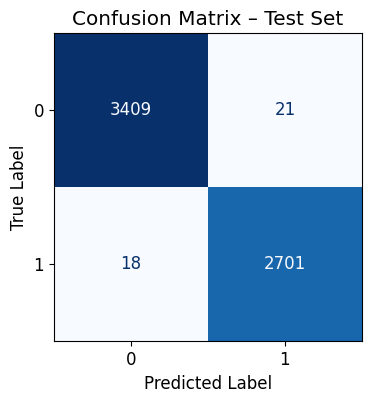

In [19]:
cm = confusion_matrix(y_idx, y_hat)
labels_sorted = learn.dls.vocab[1]  # category names from dataloader

#Plot
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title("Confusion Matrix – Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)

img_dir = Path(out_dir) / "imgs"
os.makedirs(img_dir, exist_ok=True)
save_path = img_dir / "CM-LSTM.jpg"
plt.savefig(save_path, dpi=300, bbox_inches='tight')


plt.show()

## ROC curve

In [44]:
fpr, tpr, _ = roc_curve(y_idx, preds[0][:,1])
roc_auc = auc(fpr, tpr)

print(f"The AUC is: {roc_auc:.4f}")


The AUC is: 0.9998


In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# --- Compute metrics ---
precision = precision_score(y_idx, y_hat)
recall = recall_score(y_idx, y_hat)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")

# Optional: detailed per-class report
print("\nDetailed classification report:\n")
print(classification_report(y_idx, y_hat, target_names=learn.dls.vocab[1]))


Precision: 0.992
Recall:    0.993

Detailed classification report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3430
           1       0.99      0.99      0.99      2719

    accuracy                           0.99      6149
   macro avg       0.99      0.99      0.99      6149
weighted avg       0.99      0.99      0.99      6149

